# MTA Service Reliability Analysis
## 03: Daily Ridership Analysis

---
### Imports

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import statsmodels

import calplot
import seaborn as sns

---
### Load Data

In [57]:
otp_df = pd.read_csv("../data/processed/otp_clean.csv", parse_dates=["Month"])

In [2]:
daily = pd.read_csv("../data/raw/daily_ridership_2020_to_2025.csv")
daily.head()

,Date,Subways: Total Estimated Ridership,Subways: % of Comparable Pre-Pandemic Day,Buses: Total Estimated Ridership,Buses: % of Comparable Pre-Pandemic Day,LIRR: Total Estimated Ridership,LIRR: % of Comparable Pre-Pandemic Day,Metro-North: Total Estimated Ridership,Metro-North: % of Comparable Pre-Pandemic Day,Access-A-Ride: Total Scheduled Trips,Access-A-Ride: % of Comparable Pre-Pandemic Day,Bridges and Tunnels: Total Traffic,Bridges and Tunnels: % of Comparable Pre-Pandemic Day,Staten Island Railway: Total Estimated Ridership,Staten Island Railway: % of Comparable Pre-Pandemic Day
0,01/01/2021,613692,0.29,378288,0.41,28977,0.35,14988,0.17,5960,0.44,445950,0.65,805,0.29
1,01/01/2022,1027918,0.38,350845,0.29,33980,0.35,30341,0.23,4904,0.34,498515,0.65,1262,0.31
2,01/01/2023,1675507,0.80,475226,0.52,67722,0.82,66309,0.73,11476,0.85,737533,1.08,1771,0.65
3,01/01/2024,1648734,0.79,455965,0.50,82811,1.00,73957,0.82,9165,0.68,730489,1.07,2018,0.74
4,01/01/2025,1779352,0.85,495795,0.54,90318,1.09,74690,0.83,12417,0.92,678296,0.99,2040,0.75


In [3]:
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 15 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Date                                                     1776 non-null   str    
 1   Subways: Total Estimated Ridership                       1776 non-null   int64  
 2   Subways: % of Comparable Pre-Pandemic Day                1776 non-null   float64
 3   Buses: Total Estimated Ridership                         1776 non-null   int64  
 4   Buses: % of Comparable Pre-Pandemic Day                  1776 non-null   float64
 5   LIRR: Total Estimated Ridership                          1776 non-null   int64  
 6   LIRR: % of Comparable Pre-Pandemic Day                   1776 non-null   float64
 7   Metro-North: Total Estimated Ridership                   1776 non-null   int64  
 8   Metro-North: % of Comparable Pre-Pandem

All of the rows are not null.

In [4]:
daily.describe()

,Subways: Total Estimated Ridership,Subways: % of Comparable Pre-Pandemic Day,Buses: Total Estimated Ridership,Buses: % of Comparable Pre-Pandemic Day,LIRR: Total Estimated Ridership,LIRR: % of Comparable Pre-Pandemic Day,Metro-North: Total Estimated Ridership,Metro-North: % of Comparable Pre-Pandemic Day,Access-A-Ride: Total Scheduled Trips,Access-A-Ride: % of Comparable Pre-Pandemic Day,Bridges and Tunnels: Total Traffic,Bridges and Tunnels: % of Comparable Pre-Pandemic Day,Staten Island Railway: Total Estimated Ridership,Staten Island Railway: % of Comparable Pre-Pandemic Day
count,1.776000e+03,1776.000000,1.776000e+03,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1776.000000,1.776000e+03,1776.000000,1776.000000,1776.000000
mean,2.541830e+06,0.563615,1.011409e+06,0.551644,138783.668919,0.607432,117522.400338,0.525631,22349.481982,0.878846,8.572596e+05,0.937297,4491.962838,0.387934
std,1.067641e+06,0.201075,4.369798e+05,0.191883,72243.727072,0.308112,67232.358363,0.272096,8232.384206,0.257712,1.412100e+05,0.144921,2700.110378,0.202076
min,1.983990e+05,0.070000,5.498000e+03,0.010000,1903.000000,0.020000,3281.000000,0.030000,2506.000000,0.130000,1.567590e+05,0.180000,0.000000,0.000000
25%,1.735692e+06,0.420000,7.186188e+05,0.530000,80255.750000,0.377500,53755.000000,0.310000,16250.000000,0.720000,8.139142e+05,0.910000,2121.500000,0.260000
50%,2.505354e+06,0.610000,1.143659e+06,0.600000,127684.500000,0.620000,111431.000000,0.575000,22462.000000,0.850000,8.972120e+05,0.980000,4568.500000,0.400000
75%,3.476191e+06,0.700000,1.350378e+06,0.650000,201384.750000,0.770000,180373.250000,0.720000,28125.000000,1.060000,9.472925e+05,1.020000,6845.500000,0.470000
max,5.498809e+06,1.430000,2.244515e+06,1.260000,321569.000000,2.570000,249585.000000,2.110000,41858.000000,1.770000,1.043802e+06,1.200000,17453.000000,1.820000


---
### Data Cleaning

In [5]:
daily["Date"] = pd.to_datetime(daily["Date"])

Rename columns to shorter strings.

In [7]:
daily = daily.rename(columns={
    "Date": "date",
    "Subways: Total Estimated Ridership": "subway_ridership",
    "Subways: % of Comparable Pre-Pandemic Day": "subway_pct_prepandemic",
    "Buses: Total Estimated Ridership": "bus_ridership",
    "Buses: % of Comparable Pre-Pandemic Day": "bus_pct_prepandemic",
    "LIRR: Total Estimated Ridership": "lirr_ridership",
    "LIRR: % of Comparable Pre-Pandemic Day": "lirr_pct_prepandemic",
    "Metro-North: Total Estimated Ridership": "metro_north_ridership",
    "Metro-North: % of Comparable Pre-Pandemic Day": "metro_north_pct_prepandemic",
    "Access-A-Ride: Total Scheduled Trips": "access_a_ride_trips",
    "Access-A-Ride: % of Comparable Pre-Pandemic Day": "access_a_ride_pct_prepandemic",
    "Bridges and Tunnels: Total Traffic": "bridges_tunnels_traffic",
    "Bridges and Tunnels: % of Comparable Pre-Pandemic Day": "bridges_tunnels_pct_prepandemic",
    "Staten Island Railway: Total Estimated Ridership": "sir_ridership",
    "Staten Island Railway: % of Comparable Pre-Pandemic Day": "sir_pct_prepandemic"
})

Sort by date.

In [11]:
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)

---
### Feature Engineering

Parse date into year, month, whether it's a weekday and what week number it is.

In [44]:
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["weekday"] = daily["date"].dt.day_name()
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
daily["week"] = daily["date"].dt.isocalendar().week

In [9]:
daily.head()

,date,subway_ridership,subway_pct_prepandemic,bus_ridership,bus_pct_prepandemic,lirr_ridership,lirr_pct_prepandemic,metro_north_ridership,metro_north_pct_prepandemic,access_a_ride_trips,access_a_ride_pct_prepandemic,bridges_tunnels_traffic,bridges_tunnels_pct_prepandemic,sir_ridership,sir_pct_prepandemic,year,month,weekday,week
0,2021-01-01,613692,0.29,378288,0.41,28977,0.35,14988,0.17,5960,0.44,445950,0.65,805,0.29,2021,1,Friday,53
1,2022-01-01,1027918,0.38,350845,0.29,33980,0.35,30341,0.23,4904,0.34,498515,0.65,1262,0.31,2022,1,Saturday,52
2,2023-01-01,1675507,0.80,475226,0.52,67722,0.82,66309,0.73,11476,0.85,737533,1.08,1771,0.65,2023,1,Sunday,52
3,2024-01-01,1648734,0.79,455965,0.50,82811,1.00,73957,0.82,9165,0.68,730489,1.07,2018,0.74,2024,1,Monday,1
4,2025-01-01,1779352,0.85,495795,0.54,90318,1.09,74690,0.83,12417,0.92,678296,0.99,2040,0.75,2025,1,Wednesday,1


---
### Exploratory Data Analysis

Function to format the y-axis in millions instead of scientific notation like 1e6.

In [16]:
def millions(x, pos):
    return f"{x/1e6:.1f}M"

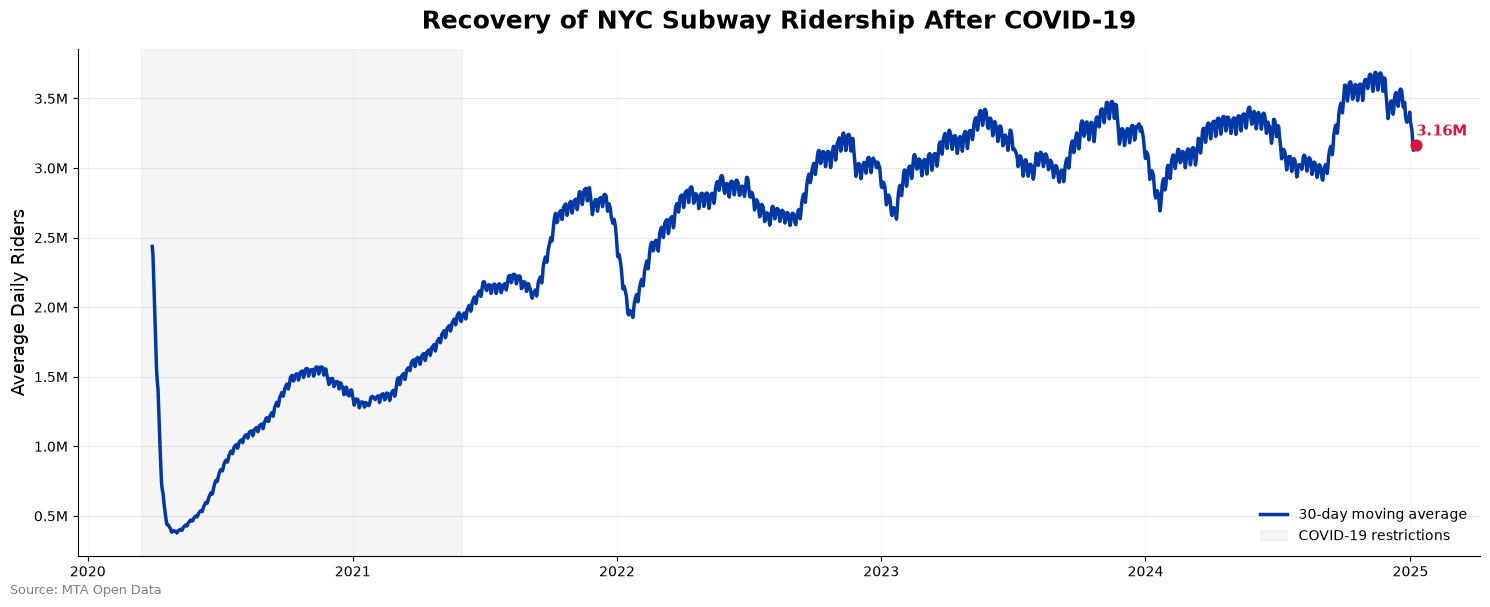

In [34]:
daily["rolling30"] = (
    daily["subway_ridership"]
    .rolling(window=30)
    .mean()
)

plt.style.use("default")

fig, ax = plt.subplots(figsize=(15,6))

ax.plot(
    daily["date"],
    daily["rolling30"],
    color="#0039A6",
    linewidth=2.5,
    label="30-day moving average"
)

# Pandemic period
ax.axvspan(
    pd.Timestamp("2020-03-15"),
    pd.Timestamp("2021-06-01"),
    color="gray",
    alpha=0.08,
    label="COVID-19 restrictions"
)

# Last observation
ax.scatter(
    daily["date"].iloc[-1],
    daily["rolling30"].iloc[-1],
    color="crimson",
    s=60,
    zorder=5
)

ax.text(
    daily["date"].iloc[-1],
    daily["rolling30"].iloc[-1] + 70000,
    f"{daily['rolling30'].iloc[-1]/1e6:.2f}M",
    fontsize=11,
    weight="bold",
    color="crimson"
)

# Format y-axis in millions
ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.set_title(
    "Recovery of NYC Subway Ridership After COVID-19",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Average Daily Riders", fontsize=13)
ax.set_xlabel("")

# Year ticks
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Clean up
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", alpha=0.10)
ax.legend(frameon=False)

plt.figtext(
    0.01,
    0.001,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Subway ridership dropped sharply at the beginning of the COVID-19 pandemic but has steadily recovered over the following years. Although there are regular seasonal fluctuations, the overall trend remains upward, reaching over 3 million average daily riders by early 2025.

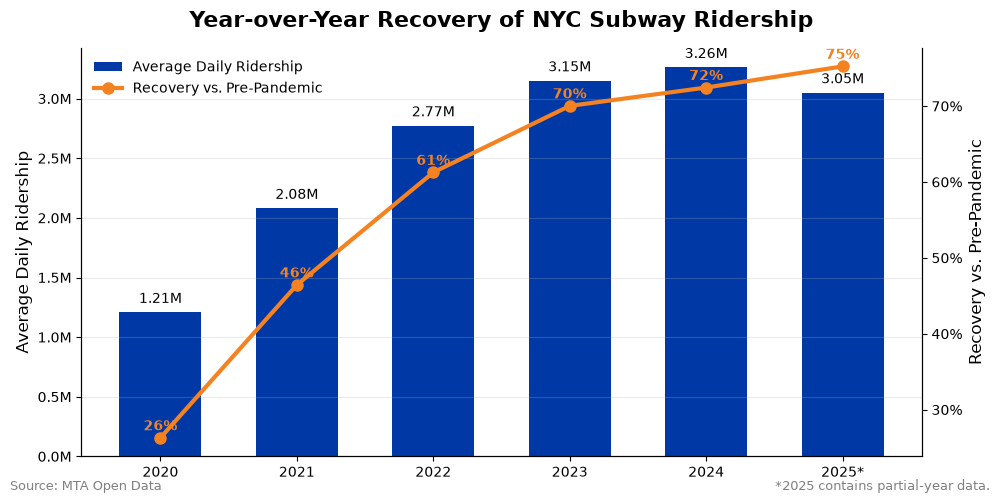

In [40]:
yearly = daily.groupby("year").agg(
    avg_ridership=("subway_ridership", "mean"),
    pct=("subway_pct_prepandemic", "mean")
)

years = ["2020", "2021", "2022", "2023", "2024", "2025*"]

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart
bars = ax1.bar(
    years,
    yearly["avg_ridership"],
    color="#0039A6",
    width=0.6,
    label="Average Daily Ridership"
)

ax1.set_ylabel("Average Daily Ridership", fontsize=12)
ax1.yaxis.set_major_formatter(FuncFormatter(millions))
ax1.grid(axis="y", alpha=0.25)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50000,
        f"{height/1e6:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Line chart for recovery percentage
ax2 = ax1.twinx()

line = ax2.plot(
    years,
    yearly["pct"] * 100,
    color="#F58220",
    marker="o",
    linewidth=3,
    markersize=8,
    label="Recovery vs. Pre-Pandemic"
)

ax2.set_ylabel("Recovery vs. Pre-Pandemic", fontsize=12)
ax2.yaxis.set_major_formatter(PercentFormatter())

# Add labels above points
for x, y in zip(years, yearly["pct"] * 100):
    ax2.text(
        x,
        y + 1,
        f"{y:.0f}%",
        ha="center",
        fontsize=10,
        color="#F58220",
        fontweight="bold"
    )

plt.title(
    "Year-over-Year Recovery of NYC Subway Ridership",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    frameon=False
)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.figtext(
    0.99,
    0.01,
    "*2025 contains partial-year data.",
    ha="right",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Average daily subway ridership increased consistently from 1.21 million in 2020 to over 3 million riders by 2024, while recovery relative to pre-pandemic levels improved from 26% to 72%. Although the 2025 average appears slightly lower, this reflects partial-year data rather than a decline in ridership.

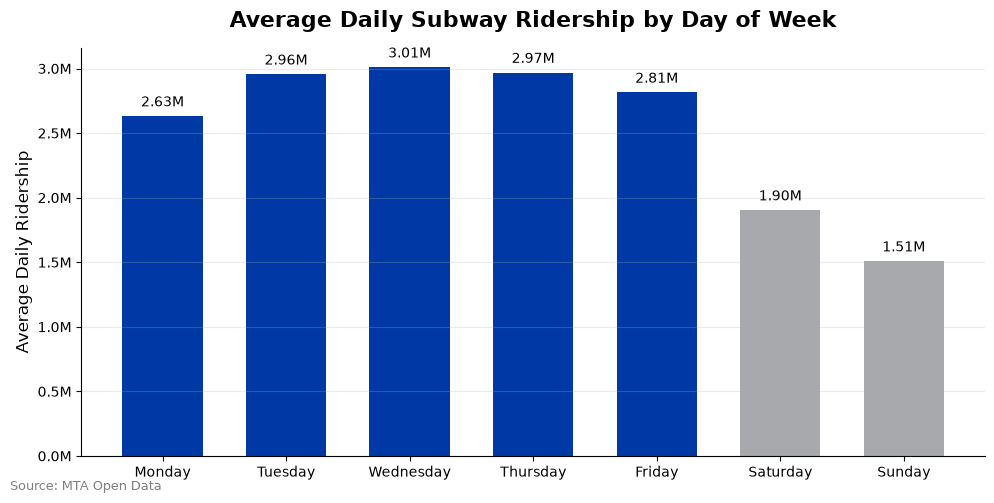

In [46]:
weekday = (
    daily
    .groupby("weekday")["subway_ridership"]
    .mean()
    .reindex(order)
)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(
    weekday.index,
    weekday.values,
    color="#0039A6",
    width=0.65
)

ax.set_title(
    "Average Daily Subway Ridership by Day of Week",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Average Daily Ridership", fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 50000,
        f"{height/1e6:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

colors = [
    "#0039A6",  # Monday
    "#0039A6",  # Tuesday
    "#0039A6",  # Wednesday
    "#0039A6",  # Thursday
    "#0039A6",  # Friday
    "#A7A9AC",  # Saturday
    "#A7A9AC",  # Sunday
]

bars = ax.bar(
    weekday.index,
    weekday.values,
    color=colors,
    width=0.65
)

plt.tight_layout()
plt.show()

**Insight:**

Average subway ridership is highest during the middle of the workweek, peaking on Wednesday at approximately 3.01 million daily riders. Ridership gradually declines toward the weekend, with Saturday averaging 1.90 million riders and Sunday dropping further to 1.51 million, reflecting typical weekday commuting patterns.

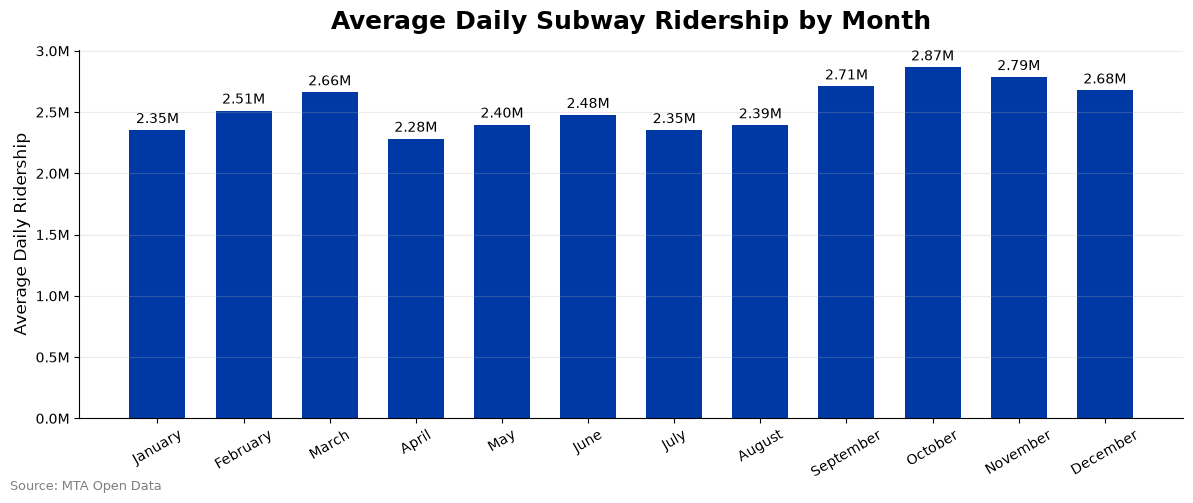

In [48]:
daily["month"] = daily["date"].dt.month_name()

order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly = (
    daily
    .groupby("month")["subway_ridership"]
    .mean()
    .reindex(order)
)

fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    monthly.index,
    monthly.values,
    color="#0039A6",
    width=0.65
)

ax.set_title(
    "Average Daily Subway Ridership by Month",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Average Daily Ridership", fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 30000,
        f"{height/1e6:.2f}M",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insight:**

Average daily subway ridership tends to increase during the fall, reaching its highest level in October (2.87 million riders). Ridership is generally lower during the spring and summer months, with April recording the lowest average (2.28 million riders). These results suggest that subway demand varies throughout the year, although part of this pattern is influenced by the overall recovery from the pandemic.

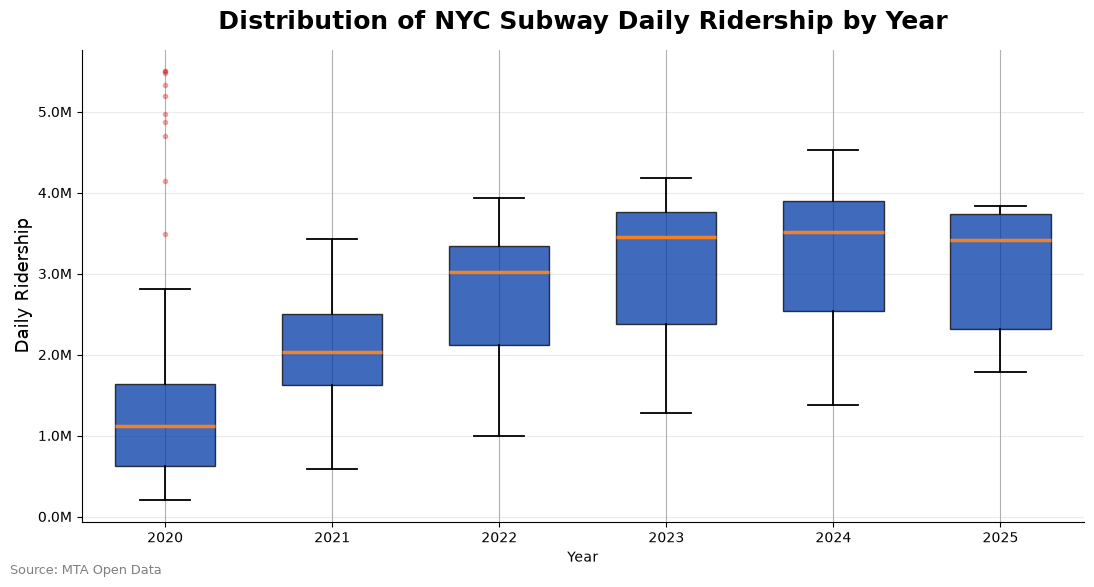

In [52]:
fig, ax = plt.subplots(figsize=(11,6))

daily.boxplot(
    column="subway_ridership",
    by="year",
    ax=ax,
    patch_artist=True,
    widths=0.6,
    boxprops=dict(facecolor="#0039A6", alpha=0.75, edgecolor="black"),
    medianprops=dict(color="#F58220", linewidth=2.5),
    whiskerprops=dict(color="black", linewidth=1.3),
    capprops=dict(color="black", linewidth=1.3),
    flierprops=dict(
        marker="o",
        markerfacecolor="#D62728",
        markeredgecolor="#D62728",
        markersize=3,
        alpha=0.35
    )
)

ax.set_title(
    "Distribution of NYC Subway Daily Ridership by Year",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Daily Ridership", fontsize=13)

ax.yaxis.set_major_formatter(FuncFormatter(millions))

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle("")

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

(<Figure size 1500x1000 with 7 Axes>,
 array([<Axes: ylabel='2020'>, <Axes: ylabel='2021'>,
        <Axes: ylabel='2022'>, <Axes: ylabel='2023'>,
        <Axes: ylabel='2024'>, <Axes: ylabel='2025'>], dtype=object))

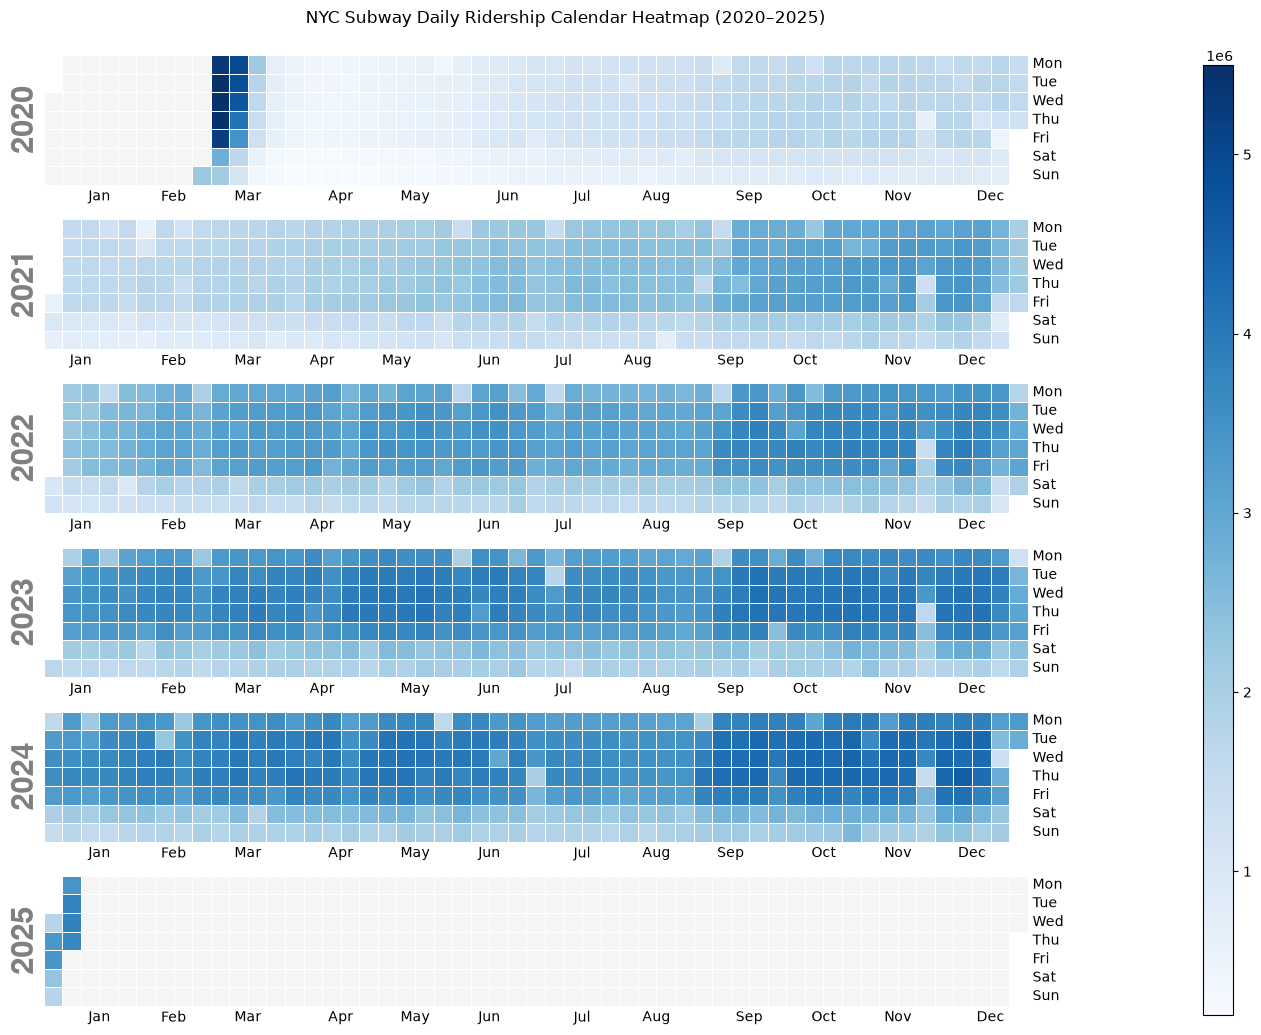

In [55]:
series = (
    daily
    .set_index("date")
    ["subway_ridership"]
)

calplot.calplot(
    series,
    cmap="Blues",
    figsize=(15,10),
    linewidth=0.5,
    edgecolor="white",
    colorbar=True,
    suptitle="NYC Subway Daily Ridership Calendar Heatmap (2020–2025)",
    yearlabel_kws={"fontsize":22},
)

**Insight:**

The calendar heatmap clearly shows the dramatic drop in subway ridership during March 2020, followed by a gradual recovery over the next several years. Each year becomes progressively darker, indicating higher daily ridership, while weekends remain consistently lighter than weekdays, reflecting lower weekend travel. By 2024, ridership is much more stable and closer to pre-pandemic levels than in earlier years.

In [59]:
merged = daily.merge(
    otp_df,
    left_on="date",
    right_on="Month",
    how="inner"
)
merged.head()

,date,subway_ridership,subway_pct_prepandemic,bus_ridership,bus_pct_prepandemic,lirr_ridership,lirr_pct_prepandemic,metro_north_ridership,metro_north_pct_prepandemic,access_a_ride_trips,...,weekday,week,rolling30,Month,division,Line,Day Type,num_on_time_trips,num_sched_trips,terminal_on_time_performance
0,2020-03-01,2212965,0.97,984908,0.99,86790,1.0,55825,0.59,19922,...,Sunday,9,NaN,2020-03-01,A DIVISION,1,1,6403,6952,0.921030
1,2020-03-01,2212965,0.97,984908,0.99,86790,1.0,55825,0.59,19922,...,Sunday,9,NaN,2020-03-01,A DIVISION,1,2,2111,2227,0.947912
2,2020-03-01,2212965,0.97,984908,0.99,86790,1.0,55825,0.59,19922,...,Sunday,9,NaN,2020-03-01,A DIVISION,2,1,4121,4864,0.847245
3,2020-03-01,2212965,0.97,984908,0.99,86790,1.0,55825,0.59,19922,...,Sunday,9,NaN,2020-03-01,A DIVISION,2,2,1123,1508,0.744695
4,2020-03-01,2212965,0.97,984908,0.99,86790,1.0,55825,0.59,19922,...,Sunday,9,NaN,2020-03-01,A DIVISION,3,1,4143,4500,0.920667


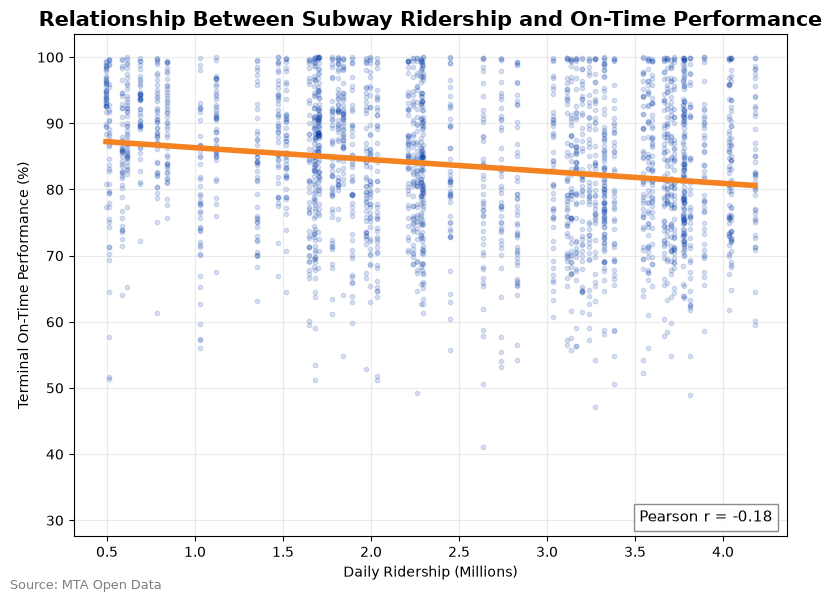

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged["subway_ridership"] / 1e6,
    merged["terminal_on_time_performance"] * 100,
    alpha=0.15,
    s=10,
    color="#0039A6"
)

z = np.polyfit(
    merged["subway_ridership"] / 1e6,
    merged["terminal_on_time_performance"] * 100,
    1
)

x = np.linspace(
    merged["subway_ridership"].min() / 1e6,
    merged["subway_ridership"].max() / 1e6,
    100
)

plt.plot(
    x,
    np.poly1d(z)(x),
    color="#F58220",
    linewidth=4,
    label="Trend"
)

r = merged["subway_ridership"].corr(
    merged["terminal_on_time_performance"]
)

plt.title(
    "Relationship Between Subway Ridership and On-Time Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Daily Ridership (Millions)")
plt.ylabel("Terminal On-Time Performance (%)")

# plt.legend(frameon=False)

plt.grid(alpha=0.25)

plt.text(
    0.98,
    0.03,
    f"Pearson r = {r:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.figtext(
    0.01,
    0.01,
    "Source: MTA Open Data",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

**Insights:**

There is a weak negative relationship between subway ridership and terminal on-time performance (Pearson r = -0.18). As daily ridership increases, on-time performance tends to decline slightly, but the large spread of the data suggests that ridership alone is not a strong predictor of service reliability.

**Key Findings:**

* Ridership steadily recovered from 2020 through 2024.
* Weekday ridership is substantially higher than weekend ridership.
* Ridership peaks during the fall months (September–November).
* Ridership has only a weak negative correlation with on-time performance (r ≈ −0.18), suggesting other operational factors play a larger role.

---
### Save Data

In [70]:
daily.to_csv("../data/processed/daily_ridership.csv", index=False)